<a href="https://colab.research.google.com/github/PaulinaG27/Ciencia-Datos/blob/main/sesiones_practicas%20/sp_5_Julian_Isaza_Paulina_Garcia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_5_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

2. En un nuevo notebook, aplica las etapas del proceso de limpieza e imputación de datos que consideres necesarias sobre el DataFrame df. Ten encuenta incluir:
    - Código correctamente comentado y ejecutado.
    - Explicaciones breves de cada paso.
    - Resultados visuales o estadísticos que evidencien las transformaciones.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

print("DataFrame original:")
display(df)

DataFrame original:


,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,NaN,Medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12
5,Luis,25.0,Bogotá,NaN,None
6,Sofía,NaN,Cali,4700.0,2023-01-15


In [ ]:
#Detección de valores faltantes

# Resumen de valores nulos por columna
print("Valores nulos por columna (Conteo):")
print(df.isnull().sum())

# Porcentaje de valores faltantes
print("\nPorcentaje de datos faltantes por columna (%):")
print((df.isnull().mean() * 100).round(2))

Valores nulos por columna (Conteo):
Nombre          1
Edad            3
Ciudad          1
Ingreso         2
FechaIngreso    2
dtype: int64

Porcentaje de datos faltantes por columna (%):
Nombre          14.29
Edad            42.86
Ciudad          14.29
Ingreso         28.57
FechaIngreso    28.57
dtype: float64


**Explicación:** La función isnull().sum() nos permite identificar rápidamente qué variables requieren imputación y podemos ver que todas las columnas excepto el índice tienen al menos un dato faltante.

In [ ]:
#Limpieza

# Identificamos que hay una edad negativa (-5) y la reemplazaremos por np.nan
df.loc[df['Edad'] < 0, 'Edad'] = np.nan

print("Valores de Edad después de corregir el error:")
print(df['Edad'].values)

Valores de Edad después de corregir el error:
[25. nan 35. 29. nan 25. nan]


**Explicación:** El valor -5 en la columna Edad es inválido en el contexto. Al convertirlo en nulo, evitamos que haya sesgo los cálculos estadísticos como la media o la mediana durante la imputación.

In [ ]:
df_limpio = df.copy()

# 1. Variables Categóricas (Nombre y Ciudad)
df_limpio['Nombre'] = df_limpio['Nombre'].fillna('Desconocido')

# Para Ciudad, imputamos con la Moda
moda_ciudad = df_limpio['Ciudad'].mode()[0]
df_limpio['Ciudad'] = df_limpio['Ciudad'].fillna(moda_ciudad)

# 2. Variables Numéricas (Edad e Ingreso)
mediana_edad = df_limpio['Edad'].median()
df_limpio['Edad'] = df_limpio['Edad'].fillna(mediana_edad)

mediana_ingreso = df_limpio['Ingreso'].median()
df_limpio['Ingreso'] = df_limpio['Ingreso'].fillna(mediana_ingreso)

# 3. Fechas (FechaIngreso)
df_limpio['FechaIngreso'] = pd.to_datetime(df_limpio['FechaIngreso'])
df_limpio['FechaIngreso'] = df_limpio['FechaIngreso'].ffill()

print("DataFrame Limpio e Imputado:")
display(df_limpio)

DataFrame Limpio e Imputado:


,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,27.0,Medellín,4800.0,2023-01-05
2,Pedro,35.0,Bogotá,4800.0,2023-01-05
3,Desconocido,29.0,Medellín,5200.0,2023-01-10
4,Marta,27.0,Cali,5100.0,2023-01-12
5,Luis,25.0,Bogotá,4800.0,2023-01-12
6,Sofía,27.0,Cali,4700.0,2023-01-15


**Explicación:** Aplicamos la sustitución por la moda para variables categóricas. Para las numéricas, se utiliza la mediana. Las fechas se manejan propagando la última observación válida hacia adelante (forward fill).

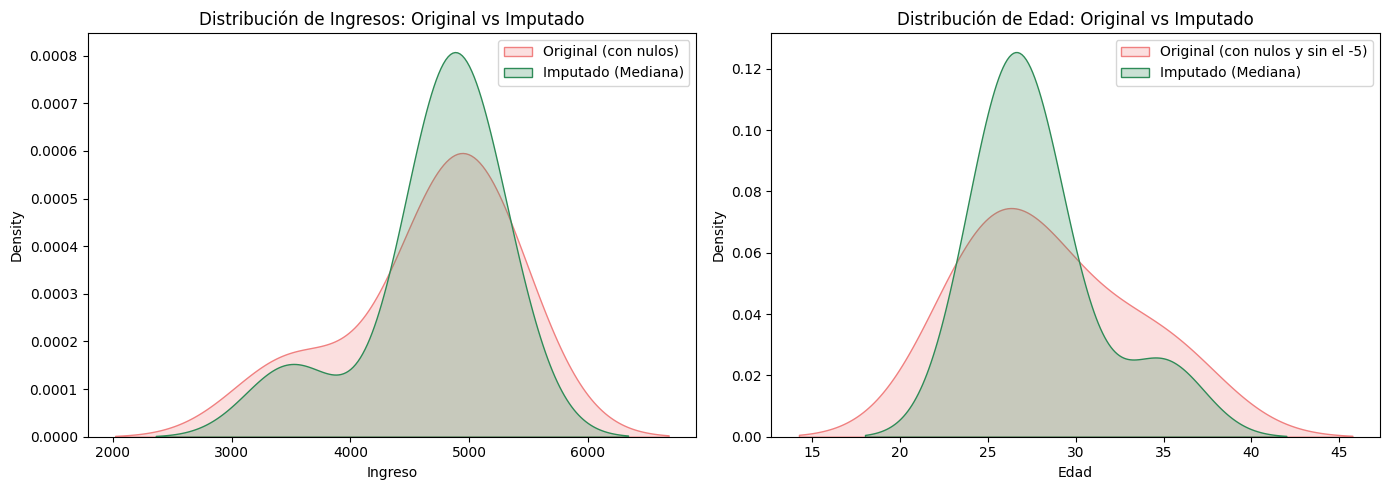

Total de valores nulos post-imputación:
 Nombre          0
Edad            0
Ciudad          0
Ingreso         0
FechaIngreso    0
dtype: int64


In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución del Ingreso Original vs Imputado
sns.kdeplot(data=df, x='Ingreso', fill=True, label='Original (con nulos)', ax=axes[0], color='lightcoral')
sns.kdeplot(data=df_limpio, x='Ingreso', fill=True, label='Imputado (Mediana)', ax=axes[0], color='seagreen')
axes[0].set_title('Distribución de Ingresos: Original vs Imputado')
axes[0].legend()

# Gráfico 2: Distribución de Edad Original vs Imputado
sns.kdeplot(data=df, x='Edad', fill=True, label='Original (con nulos y sin el -5)', ax=axes[1], color='lightcoral')
sns.kdeplot(data=df_limpio, x='Edad', fill=True, label='Imputado (Mediana)', ax=axes[1], color='seagreen')
axes[1].set_title('Distribución de Edad: Original vs Imputado')
axes[1].legend()

plt.tight_layout()
plt.show()

# Verificación final de nulos
print("Total de valores nulos post-imputación:\n", df_limpio.isnull().sum())

**Explicación:** En este paso, generamos gráficos de densidad que comparan visualmente cómo se distribuían los datos numéricos (Ingreso y Edad) originalmente frente a cómo quedaron después de rellenar los valores faltantes con la mediana, finalizando con una verificación de que ya no existen nulos en el conjunto de datos.

**Análisis de los resultados:** En este paso, visualizamos cómo cambió la distribución de los datos de Ingreso y Edad tras rellenar los valores faltantes con la mediana. Al observar ambas gráficas, vemos que las curvas rojas (datos originales) son más suaves y extendidas, mientras que las curvas verdes (datos imputados) desarrollan un pico muy agudo justo en el centro. Esto ocurre de manera idéntica en las dos variables porque, al reemplazar los espacios vacíos repitiendo exactamente el mismo número (el valor central), concentramos artificialmente un gran volumen de datos en un solo punto. El análisis nos demuestra que imputar con la mediana es una técnica rápida, pero tiene como costo la reducción de la variabilidad natural de nuestros datos.

El resultado final que muestra ceros en todas las filas confirma el éxito técnico de la limpieza, evidenciando que las estrategias seleccionadas (la moda para categorías, la mediana para números y el rellenado temporal para fechas) se aplicaron correctamente y cubrieron el 100% de los valores faltantes.

## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'ID': [101, 102, 102, 103, 104, 104, 104],
        'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
        'Edad': [25, 30, 30, 29, 40, 40, 41],
        'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
        'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                        '2023-01-15', '2023-01-15', '2023-01-16']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, responde a las siguientes preguntas (utilizando python):
    - ¿Cuál es el total de registros originales?
    - ¿Cuáles y cuántos son los duplicados exactos?
    - ¿Cuáles y cuántos son los duplicados por varias columnas?
    - ¿Cuántos registros debes eliminar?
    - ¿Cuántos registros quedan después de la limpieza?

In [ ]:
# Usaremos 'df2' para no sobreescribir el DataFrame del ejercicio anterior
df2 = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                      '2023-01-15', '2023-01-15', '2023-01-16']
})

# 1. ¿Cuál es el total de registros originales?
total_originales = len(df2)
print(f"1. Total de registros originales: {total_originales}")
display(df2)

Total de registros originales: 7


,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


In [ ]:
# 2. ¿Cuáles y cuántos son los duplicados exactos?
duplicados_exactos = df2[df2.duplicated(keep=False)]

cantidad_exactos = df2.duplicated().sum()

print(f"2. Cantidad de duplicados exactos a eliminar: {cantidad_exactos}")
print("Filas exactas repetidas:")
display(duplicados_exactos)


duplicados_id = df2[df2.duplicated(subset=['ID'], keep=False)]
cantidad_id_sobrantes = df2.duplicated(subset=['ID']).sum()

print(f"\n 3. Cantidad de duplicados por 'ID' a eliminar: {cantidad_id_sobrantes}")
print("Filas con el mismo 'ID' (notar el caso del ID 104):")
display(duplicados_id)

2. Cantidad de duplicados exactos a eliminar: 2
Filas exactas repetidas:


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15



 3. Cantidad de duplicados por 'ID' a eliminar: 3
Filas con el mismo 'ID' (notar el caso del ID 104):


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


**Explicación:** El ID 102 (Luis) es un duplicado exacto. Sin embargo, el ID 104 (Carlos) tiene un duplicado exacto y una tercera entrada donde su edad y fecha cambian (41 años, un día después). Esto es un duplicado lógico que también debe limpiarse.

In [ ]:
# 4 y 5. Limpieza y conteo final

df2_limpio = df2.drop_duplicates(subset=['ID'], keep='last')

registros_finales = len(df2_limpio)
registros_eliminados = total_originales - registros_finales

print(f"4. Registros eliminados en el proceso: {registros_eliminados}")
print(f"5. Registros que quedan después de la limpieza: {registros_finales}")
print("\nDataFrame Final Limpio:")
display(df2_limpio)

4. Registros eliminados en el proceso: 3
5. Registros que quedan después de la limpieza: 4

DataFrame Final Limpio:


,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
6,104,Carlos,41,Cali,2023-01-16


**1. ¿Cuál es el total de registros originales?**
El total de registros (filas) en el DataFrame original es de 7.

**2. ¿Cuáles y cuántos son los duplicados exactos?**
Hay 2 registros que son duplicados exactos (idénticos en todas sus columnas):

El registro de Luis (ID 102, Edad 30, Cali, 2023-01-05).

El primer registro de Carlos (ID 104, Edad 40, Cali, 2023-01-15).

**3. ¿Cuáles y cuántos son los duplicados por varias columnas?**
Si analizamos por la columna ID (ya que un identificador debería ser único para cada persona), encontramos 1 duplicado adicional lógico:

El segundo registro de Carlos (ID 104), que tiene datos diferentes (Edad 41, Fecha 2023-01-16) pero comparte el mismo identificador que los registros anteriores.
(Nota: En total, hay 3 filas que sobran por tener un ID repetido, sumando los exactos y los lógicos).

**4. ¿Cuántos registros debes eliminar?**
Se deben eliminar 3 registros en total (los 2 duplicados exactos + 1 registro desactualizado de Carlos).

**5. ¿Cuántos registros quedan después de la limpieza?**
Quedan 4 registros únicos en el DataFrame limpio (uno para Ana, uno para Luis, uno para Marta y la versión más reciente de Carlos).

## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, estandariza la variable ciudad utilizando python.

In [ ]:
import pandas as pd
import unicodedata

df3 = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

print("--- EJERCICIO 3: CORRECCIÓN DE ERRORES TIPOGRÁFICOS ---\n")
print("1. Valores Originales:")
# value_counts() nos muestra cuántas variaciones diferentes existen
print(df3['Ciudad'].value_counts())
print("\n" + "-"*40 + "\n")

# Función para estandarizar el texto
def estandarizar_texto(texto):
    if pd.isna(texto):
        return texto

    texto = str(texto).lower()

    texto = ''.join(c for c in unicodedata.normalize('NFKD', texto)
                  if unicodedata.category(c) != 'Mn')

    texto = texto.strip()

    correcciones = {
        'bogata': 'bogota'
    }
    texto = correcciones.get(texto, texto)

    texto = texto.title()

    return texto

# Aplicamos la función a la columna
df3_estandarizado = df3.copy()
df3_estandarizado['Ciudad'] = df3_estandarizado['Ciudad'].apply(estandarizar_texto)

# Resultados Finales
print("2. Valores Estandarizados:")
print(df3_estandarizado['Ciudad'].value_counts())
print("\nDataFrame Resultante:")
display(df3_estandarizado)

--- EJERCICIO 3: CORRECCIÓN DE ERRORES TIPOGRÁFICOS ---

1. Valores Originales:
Ciudad
bogota      1
Bogotá      1
BOGOTA      1
bogotá      1
bogata      1
Bógota      1
BogoTa      1
Cali        1
calí        1
medellín    1
medellin    1
Name: count, dtype: int64

----------------------------------------

2. Valores Estandarizados:
Ciudad
Bogota      7
Cali        2
Medellin    2
Name: count, dtype: int64

DataFrame Resultante:


,Ciudad
0,Bogota
1,Bogota
2,Bogota
3,Bogota
4,Bogota
5,Bogota
6,Bogota
7,Cali
8,Cali
9,Medellin


## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
   - **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
   

### 📊 Ejercicio 4. Identificación de mecanismos de datos faltantes

A continuación, se clasifican los diferentes escenarios según el tipo de mecanismo de datos faltantes (**MCAR**, **MAR**, o **MNAR**) junto con su respectiva justificación:

---

#### 📌 Escenario 1
> *Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).*

* 🏷️ **Clasificación:** **MCAR** (Missing Completely at Random).
*  **Justificación:** La ausencia del dato es un evento completamente accidental y no depende de ninguna otra variable observada ni del propio valor ausente.

---

#### 📌 Escenario 2
> *Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.*

* 🏷️ **Clasificación:** **MAR** (Missing at Random).
*  **Justificación:** La probabilidad de que falte el dato depende directamente de otra variable que sí observamos y tenemos registrada en la base de datos (el promedio académico)

---

#### 📌 Escenario 3
> *Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.*

* 🏷️ **Clasificación:** **MAR** (Missing at Random).
*  **Justificación:** (Es idéntico al Escenario 2). La falta de datos se puede modelar porque está explicada por otra variable observada en el conjunto.
---


#### 📌 Escenario 4
> *Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.*

* 🏷️ **Clasificación:** **MAR** (Missing at Random).
*  **Justificación:** La ausencia de datos en el promedio académico está sistemáticamente relacionada y explicada por otra variable conocida (el género del estudiante).

---

#### 📌 Escenario 5
> *Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.*

* 🏷️ **Clasificación:** **MNAR** (Missing Not at Random).
*  **Justificación:** La falta de datos depende directamente del propio valor que está ausente (ocultan el dato precisamente porque es bajo), lo cual es el escenario más complejo y genera sesgo.

## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Edad': np.random.randint(18, 60, n),
            'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
            'Horas_estudio': np.random.randint(0, 40, n),
            'Ingreso_familiar': np.random.randint(800000, 8000000, n),
            'Semestres_cursados': np.random.randint(1, 10, n)
        })

        # Introducción de valores faltantes con distintos patrones
        df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
        df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
        df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

2. Al analizar el dataframe `df`:
   - ¿Qué variables tienen mayor proporción de datos faltantes?
   - ¿Observas algún patrón estructurado o parecen aleatorios?

3. Realiza la imputación de valores faltantes utilizando KNN y regresión
4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

# 2. Análisis de datos faltantes
print("PROPORCIÓN DE DATOS FALTANTES")
proporcion_faltantes = (df.isnull().sum() / len(df)) * 100
print(proporcion_faltantes[proporcion_faltantes > 0].sort_values(ascending=False))

PROPORCIÓN DE DATOS FALTANTES
Promedio            13.333333
Horas_estudio       13.333333
Ingreso_familiar    10.000000
dtype: float64


* **¿Qué variables tienen mayor proporción de datos faltantes?**

  Las variables *Promedio* y *Horas_estudio* tienen la mayor proporción, ambas con un **13.33%** de datos faltantes (4 registros de 30) y les sigue *Ingreso_familiar* con un **10%** (3 registros).

---

* **¿Observas algún patrón estructurado o parecen aleatorios?**

  Parecen completamente aleatorios **(MCAR)**.  
  Los índices donde faltan los datos (ejm. 2, 5, 8 para *Promedio* y 1, 7, 10 para *Horas*) no se superponen ni muestran una relación lógica con el resto de las variables, entonces fueron introducidos al azar de manera artificial.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import MinMaxScaler

# Hacemos copias para cada método
df_knn_imputed = df.copy()
df_reg_imputed = df.copy()

# IMPUTACIÓN CON KNN
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

knn_imputer = KNNImputer(n_neighbors=3)
df_knn_scaled = pd.DataFrame(knn_imputer.fit_transform(df_scaled), columns=df.columns)

df_knn = pd.DataFrame(scaler.inverse_transform(df_knn_scaled), columns=df.columns)


# IMPUTACIÓN POR REGRESIÓN
reg_imputer = IterativeImputer(random_state=42)
df_reg = pd.DataFrame(reg_imputer.fit_transform(df), columns=df.columns)

print("Imputación finalizada")

Imputación finalizada


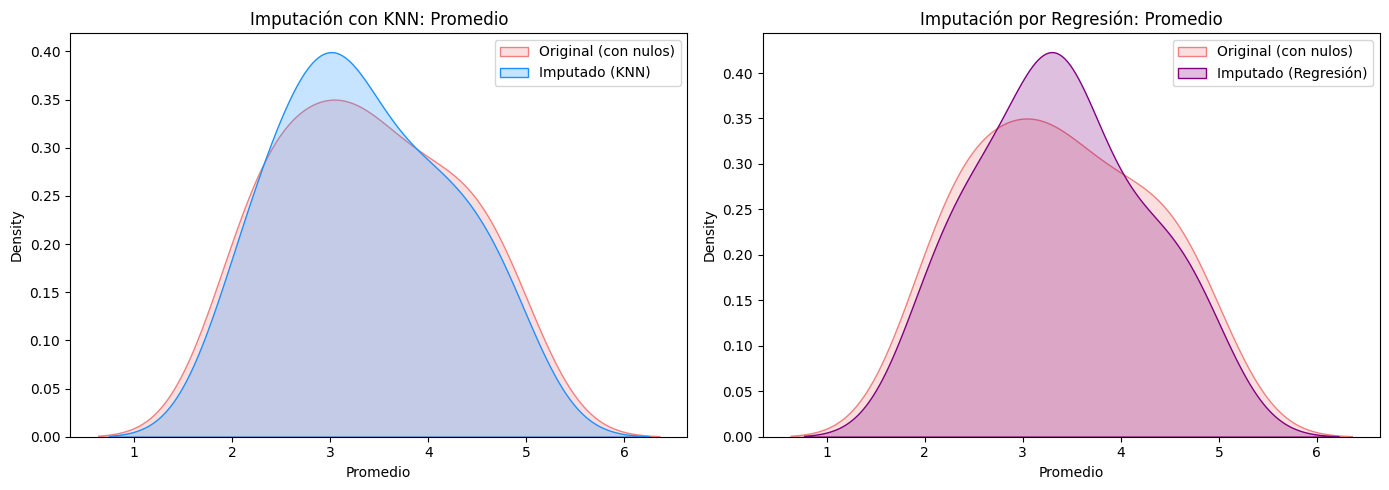

In [ ]:
# ANÁLISIS VISUAL DE LA IMPUTACIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='Promedio', fill=True, label='Original (con nulos)', ax=axes[0], color='lightcoral')
sns.kdeplot(data=df_knn, x='Promedio', fill=True, label='Imputado (KNN)', ax=axes[0], color='dodgerblue')
axes[0].set_title('Imputación con KNN: Promedio')
axes[0].legend()

# Gráfico para Regresión
sns.kdeplot(data=df, x='Promedio', fill=True, label='Original (con nulos)', ax=axes[1], color='lightcoral')
sns.kdeplot(data=df_reg, x='Promedio', fill=True, label='Imputado (Regresión)', ax=axes[1], color='purple')
axes[1].set_title('Imputación por Regresión: Promedio')
axes[1].legend()

plt.tight_layout()
plt.show()

* **¿Se preserva la naturaleza de los datos?**

  Sí, a diferencia de la imputación simple con la mediana (que generaba picos artificiales en el centro), tanto KNN como la Regresión hacen un mejor trabajo preservando la naturaleza, forma y variabilidad de la distribución original.  

* **KNN:** Estima los valores buscando a los 3 "estudiantes" más similares en las demás variables, lo que resulta en valores imputados muy realistas y acordes a la variabilidad natural del grupo.

* **Regresión:** Modela las relaciones lineales entre todas las variables para predecir el dato faltante, conservando la tendencia general de los datos sin concentrarlos todos en un único punto.

## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
            'Ventas': np.round(np.random.uniform(100, 500, n), 2),
            'Inventario': np.random.randint(10, 100, n),
            'Clientes': np.random.randint(1, 50, n)
        })

        # Introducción de valores faltantes
        df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
        df.loc[[7, 8, 20], 'Inventario'] = np.nan
        df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
        df = df.sort_values('Fecha').reset_index(drop=True)

2. Al analizar el DataFrame `df`:
   - ¿Qué variables presentan datos faltantes consecutivos?
   - ¿Por qué este tipo de patrón es relevante en series temporales?
   - ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?
3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?

In [7]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
     'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
     'Ventas': np.round(np.random.uniform(100, 500, n), 2),
     'Inventario': np.random.randint(10, 100, n),
     'Clientes': np.random.randint(1, 50, n)
    })
# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)

print("Nulos por columna:")
print(df.isnull().sum())
print()
print("Filas con valores faltantes:")
display(df[df.isnull().any(axis=1)])

Nulos por columna:
Fecha         0
Ventas        5
Inventario    3
Clientes      4
dtype: int64

Filas con valores faltantes:


,Fecha,Ventas,Inventario,Clientes
1,2023-01-02,480.29,16.0,NaN
2,2023-01-03,392.80,30.0,NaN
3,2023-01-04,NaN,82.0,44.0
4,2023-01-05,NaN,48.0,34.0
5,2023-01-06,NaN,27.0,10.0
7,2023-01-08,446.47,NaN,14.0
8,2023-01-09,340.45,NaN,31.0
12,2023-01-13,NaN,62.0,14.0
13,2023-01-14,NaN,11.0,23.0
18,2023-01-19,272.78,17.0,NaN


###¿Qué variables presentan datos faltantes consecutivos?
####Ventas:
 * filas 3, 4, 5 (3 consecutivos) y 12, 13 (2 consecutivos) — es la variable con el patrón más marcado.
####Clientes:
* filas 1, 2 (2 consecutivos) y 18, 19 (2 consecutivos) — dos bloques de ausencias seguidas.
####Inventario:
* filas 7, 8 (2 consecutivos) y fila 20 (aislada) — un bloque pequeño y un valor suelto.

####¿Por qué este patrón es relevante en series temporales?

Los faltantes consecutivos son especialmente relevantes porque, como indica la definición en el colab, la interpolación y los métodos secuenciales se basan en estimar o propagar valores adyacentes para mantener la continuidad y coherencia temporal del conjunto de datos.
Primero, el contexto temporal da información. Como señala la definición, el principio de estos métodos es que los puntos conocidos antes y después del faltante permiten estimar o propagar el valor ausente. En nuestro DataFrame, por ejemplo, si Ventas es NaN los días 4 y 5 de enero, los valores del día 3 (LOCF) o del día 6 (NOCB) son estimaciones razonables porque la serie tiene continuidad cronológica.
También el método apropiado depende de la naturaleza del patrón. La definición establece en el Paso 2 que la elección entre interpolación lineal, spline, LOCF o NOCB depende de cómo se comportan los datos. Los bloques consecutivos como los de Ventas (3 días seguidos) y Clientes (2 días seguidos) hacen que LOCF y NOCB sean candidatos naturales porque conservan la tendencia local sin modificar la estructura, exactamente como describe el ejemplo del sensor de temperatura.

####¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?

El orden es una precondición técnica para que estos métodos funcionen. Como establece la definición, la interpolación y los métodos secuenciales operan sobre datos ordenados secuencialmente — sin ese orden, el "último valor observado" de LOCF o el "siguiente valor" de NOCB no tendrían ningún sentido temporal y se propagarían valores arbitrarios.

En el DataFrame esto está garantizado por la línea sort_values('Fecha').reset_index(drop=True) al construirlo.

In [8]:
df_locf = df.copy()
df_nocb = df.copy()

# LOCF
df_locf[['Ventas', 'Inventario', 'Clientes']] = (
    df_locf[['Ventas', 'Inventario', 'Clientes']].ffill()
)

# NOCB:
df_nocb[['Ventas', 'Inventario', 'Clientes']] = (
    df_nocb[['Ventas', 'Inventario', 'Clientes']].bfill()
)

print("LOCF")
display(df_locf[df_locf.index.isin([1,2,3,4,5,7,8,12,13,18,19,20])])

print("\nOCB")
display(df_nocb[df_nocb.index.isin([1,2,3,4,5,7,8,12,13,18,19,20])])

print("\nNulos restantes LOCF:", df_locf.isnull().sum().sum())
print("Nulos restantes NOCB:", df_nocb.isnull().sum().sum())

LOCF


,Fecha,Ventas,Inventario,Clientes
1,2023-01-02,480.29,16.0,29.0
2,2023-01-03,392.80,30.0,29.0
3,2023-01-04,392.80,82.0,44.0
4,2023-01-05,392.80,48.0,34.0
5,2023-01-06,392.80,27.0,10.0
7,2023-01-08,446.47,13.0,14.0
8,2023-01-09,340.45,13.0,31.0
12,2023-01-13,487.96,62.0,14.0
13,2023-01-14,487.96,11.0,23.0
18,2023-01-19,272.78,17.0,45.0



OCB


,Fecha,Ventas,Inventario,Clientes
1,2023-01-02,480.29,16.0,44.0
2,2023-01-03,392.80,30.0,44.0
3,2023-01-04,123.23,82.0,44.0
4,2023-01-05,123.23,48.0,34.0
5,2023-01-06,123.23,27.0,10.0
7,2023-01-08,446.47,23.0,14.0
8,2023-01-09,340.45,23.0,31.0
12,2023-01-13,172.73,62.0,14.0
13,2023-01-14,172.73,11.0,23.0
18,2023-01-19,272.78,17.0,24.0



Nulos restantes LOCF: 0
Nulos restantes NOCB: 0


###Análisis
LOCF es más apropiado para este conjunto de datos porque los registros diarios de ventas, inventario y clientes siguen una dirección natural del tiempo — es más razonable asumir que un día sin dato se parece al anterior que al siguiente, respetando así el principio de propagación del último valor observado que describe la definición.
La excepción sería Clientes en las filas 1 y 2, donde los faltantes están al inicio de la serie y NOCB sería la única opción válida al no haber valor previo disponible.